# Segundo Trabalho — Reconhecimento de Padrões

Notebook para as questões do **segundo** trabalho. O relatório em LaTeX será montado depois, em `documents/trabalho2/`.

**Dependências:** `numpy` (incl. `numpy.linalg.pinv` para MQ nas Q8–Q10), `matplotlib`, `scikit-learn` (Q5–Q7: `Perceptron`; Q8–Q10: MQ; Q11–Q13: `sklearn.svm.SVC` com kernel linear — SVM com margem suave; `DecisionBoundaryDisplay`, `accuracy_score`).

## Questão 1 — Definição das classes

Problema de classificação com **duas classes** em $\mathbb{R}^2$, cada uma modelada por uma **Gaussiana bidimensional** com a **mesma** matriz de covariância $\Sigma$:

- **Classe $C_1$:** $\mathbf{x} \mid C_1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma})$, com $\boldsymbol{\mu}_1 = [0,0]^\top$ e
  $$\boldsymbol{\Sigma} = \begin{bmatrix} 1 & 0{,}6 \\ 0{,}6 & 1 \end{bmatrix}.$$
- **Classe $C_2$:** $\mathbf{x} \mid C_2 \sim \mathcal{N}(\boldsymbol{\mu}_2, \boldsymbol{\Sigma})$, com $\boldsymbol{\mu}_2 = [2,0]^\top$ e a mesma $\boldsymbol{\Sigma}$.

Cada classe fica assim descrita por **dois parâmetros** (vetor média em $\mathbb{R}^2$), além da covariância **compartilhada** $\boldsymbol{\Sigma}$.

## Questão 2 — Geração de dados e gráfico com a fronteira do 1º trabalho

Conforme o enunciado:

1. Sortear um inteiro em $[0,500]$ como semente (reproduzível a partir de uma semente-mestre fixa abaixo).
2. Gerar **1000** amostras de treino para $C_1$ e **1000** para $C_2$.
3. Plotar os pontos e a **superfície de separação obtida no primeiro trabalho** para esta mesma configuração $(\boldsymbol{\mu}_1, \boldsymbol{\mu}_2, \boldsymbol{\Sigma})$ — isto é, a **fronteira ótima de Bayes** com classes equiprováveis e mesma covariância:
   $$h(\mathbf{x}) = \boldsymbol{w}^\top \mathbf{x} + b = 0,\qquad
   \boldsymbol{w} = \boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}_2-\boldsymbol{\mu}_1),\quad
   b = -\tfrac12\bigl(\boldsymbol{\mu}_2^\top\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}_2 - \boldsymbol{\mu}_1^\top\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}_1\bigr).$$

Para $\boldsymbol{\mu}_1=\mathbf{0}$, $\boldsymbol{\mu}_2=(2,0)^\top$ e a $\boldsymbol{\Sigma}$ acima, isso coincide com a *Questão 8* do primeiro trabalho: $h(\mathbf{x}) = 3{,}125\,x_1 - 1{,}875\,x_2 - 3{,}125$.

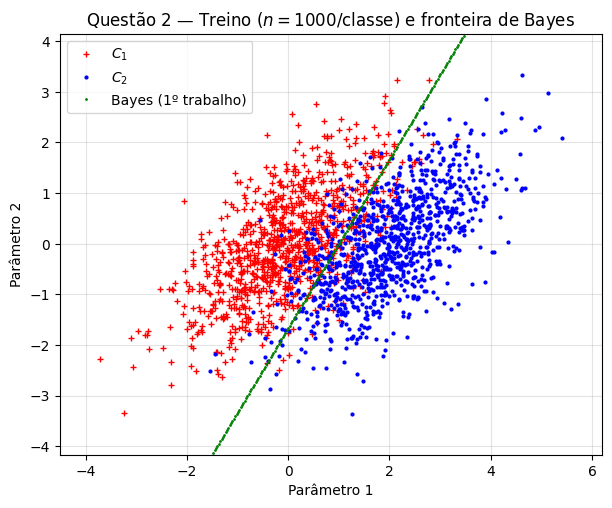

Semente sorteada (intervalo [0, 500]): 316
Fronteira: (3.1250)*x1 + (-1.8750)*x2 + (-3.1250) = 0
Figura salva em: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho2\figures\questao2_treino_fronteira_bayes_t1.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Parâmetros da Questão 1 ---
mu1 = np.array([0.0, 0.0])
mu2 = np.array([2.0, 0.0])
Sigma = np.array([[1.0, 0.6], [0.6, 1.0]])

# Fronteira de Bayes (mesma derivação do 1º trabalho; priors iguais)
Sigma_inv = np.linalg.inv(Sigma)
w = Sigma_inv @ (mu2 - mu1)
b = -0.5 * (mu2 @ Sigma_inv @ mu2 - mu1 @ Sigma_inv @ mu1)

# --- Questão 2: semente em [0, 500] e amostras ---
MASTER_SEED = 2027  # fixa a reprodutibilidade do sorteio do enunciado
seed_train = int(np.random.default_rng(MASTER_SEED).integers(0, 501))
rng = np.random.default_rng(seed_train)

n = 1000
X1 = rng.multivariate_normal(mu1, Sigma, size=n)
X2 = rng.multivariate_normal(mu2, Sigma, size=n)

FIG_DIR = Path("../documents/trabalho2/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

x_all = np.vstack([X1, X2])
pad = 0.8
x_min, y_min = x_all.min(axis=0) - pad
x_max, y_max = x_all.max(axis=0) + pad

plt.figure(figsize=(7.0, 6.2))
plt.plot(X1[:, 0], X1[:, 1], "r+", markersize=4, label="$C_1$")
plt.plot(X2[:, 0], X2[:, 1], "b.", markersize=4, label="$C_2$")

x1_line = np.linspace(x_min, x_max, 400)
if abs(w[1]) > 1e-12:
    x2_line = -(w[0] * x1_line + b) / w[1]
    m = (x2_line >= y_min) & (x2_line <= y_max)
    plt.plot(x1_line[m], x2_line[m], "g.", markersize=2, label="Bayes (1º trabalho)")
else:
    xv = np.full(300, -b / w[0])
    yv = np.linspace(y_min, y_max, 300)
    plt.plot(xv, yv, "g.", markersize=2, label="Bayes (1º trabalho)")

plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.title("Questão 2 — Treino ($n=1000$/classe) e fronteira de Bayes")
plt.grid(True, alpha=0.35)
plt.axis([x_min, x_max, y_min, y_max])
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(loc="best")

out = FIG_DIR / "questao2_treino_fronteira_bayes_t1.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Semente sorteada (intervalo [0, 500]): {seed_train}")
print(f"Fronteira: ({w[0]:.4f})*x1 + ({w[1]:.4f})*x2 + ({b:.4f}) = 0")
print(f"Figura salva em: {out.resolve()}")

## Questão 3 — Raiz do sorteio aleatório

Sortear um inteiro em $[0,500]$ a usar como **raiz** do sorteio no passo seguinte (geração do conjunto de teste, Questão 4).

Para manter o notebook **reprodutível**, o sorteio usa uma semente-mestre `MASTER_Q34` (pode alterar só este valor se quiser outro desfecho fixo).

## Questão 4 — Conjunto de teste

Gerar **novos** dados: $1000$ amostras de $C_1$ e $1000$ de $C_2$, com a mesma distribuição da Questão 1, utilizando a semente sorteada na Questão 3. Este conjunto será usado para avaliar o perceptron (e classificadores posteriores).

In [2]:
# Questões 3 e 4 — semente de teste e geração do conjunto de teste
# Requer ter executado a célula da Questão 2 (mu1, mu2, Sigma, n, X1, X2).

MASTER_Q34 = 2028
rng_q3 = np.random.default_rng(MASTER_Q34)
seed_test = int(rng_q3.integers(0, 501))

print("Questão 3 — inteiro sorteado em [0, 500] (raiz do teste):", seed_test)

rng_test = np.random.default_rng(seed_test)
X1_test = rng_test.multivariate_normal(mu1, Sigma, size=n)
X2_test = rng_test.multivariate_normal(mu2, Sigma, size=n)

X_train = np.vstack([X1, X2])
y_train = np.concatenate([np.zeros(n, dtype=int), np.ones(n, dtype=int)])
X_test = np.vstack([X1_test, X2_test])
y_test = np.concatenate([np.zeros(n, dtype=int), np.ones(n, dtype=int)])

print("Questão 4 — teste:", X_test.shape[0], "amostras (", n, "por classe).")

Questão 3 — inteiro sorteado em [0, 500] (raiz do teste): 283
Questão 4 — teste: 2000 amostras ( 1000 por classe).


## Questão 5 — Perceptron (treino completo, critério de parada, teste)

Treinar um **perceptron linear** (`sklearn.linear_model.Perceptron`) com **todo** o conjunto de treino da Questão 2. Critérios de parada usados (alinhados à prática com gradiente / atualizações limitadas nos slides):

- `max_iter`: número máximo de **épocas** (passagens completas pelos dados de treino);
- `tol`: tolerância — o algoritmo para mais cedo se a melhoria no critério interno for inferior a `tol` entre épocas consecutivas.

Em seguida: plotar a **reta de separação** sobre o **conjunto de teste** da Questão 4 e estimar a probabilidade de erro $\hat{P}_e = \frac{\#\text{erros}}{N_{\text{teste}}}$.

Questão 5 — Perceptron
  Épocas efetivas (n_iter_): 9
  Erro estimado no teste (Q4): 0.1655
  Coeficientes w = [ 0.48441271 -0.30243044],  intercepto = -0.200000


C:\Users\DELL\AppData\Local\Temp\ipykernel_15900\1179795166.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"  Coeficientes w = {clf.coef_.ravel()},  intercepto = {float(clf.intercept_):.6f}")


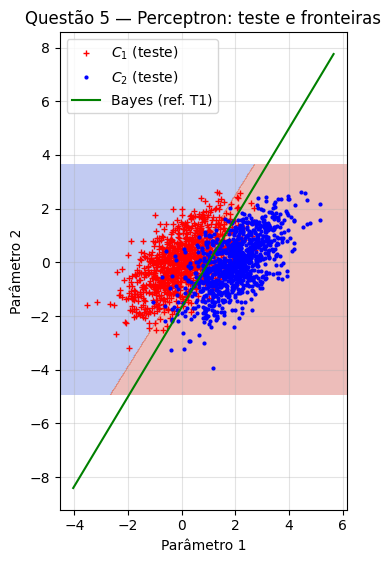

Figura salva em: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho2\figures\questao5_perceptron_teste.png


In [3]:
from sklearn.linear_model import Perceptron
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score

# --- Treino do perceptron (conjunto completo da Q2) ---
clf = Perceptron(
    penalty=None,
    alpha=0.0,
    max_iter=5000,
    tol=1e-4,
    shuffle=True,
    verbose=0,
    eta0=0.1,
    random_state=0,
    early_stopping=False,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
err_hat = 1.0 - accuracy_score(y_test, y_pred)

print("Questão 5 — Perceptron")
print(f"  Épocas efetivas (n_iter_): {clf.n_iter_}")
print(f"  Erro estimado no teste: {err_hat:.4f}")
print(f"  Coeficientes w = {clf.coef_.ravel()},  intercepto = {float(clf.intercept_):.6f}")

# --- Gráfico: dados de teste + fronteira ---
fig, ax = plt.subplots(figsize=(7.0, 6.2))
DecisionBoundaryDisplay.from_estimator(
    clf,
    X_test,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.35,
    ax=ax,
    grid_resolution=250,
)
ax.plot(X1_test[:, 0], X1_test[:, 1], "r+", markersize=4, label="$C_1$ (teste)")
ax.plot(X2_test[:, 0], X2_test[:, 1], "b.", markersize=4, label="$C_2$ (teste)")
# Linha de Bayes (referência do 1º trabalho)
x1b = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 300)
if abs(w[1]) > 1e-12:
    x2b = -(w[0] * x1b + b) / w[1]
    ax.plot(x1b, x2b, "g-", linewidth=1.5, label="Bayes (ref. T1)")
ax.set_xlabel("Parâmetro 1")
ax.set_ylabel("Parâmetro 2")
ax.set_title("Questão 5 — Perceptron: teste e fronteiras")
ax.grid(True, alpha=0.35)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")

out5 = FIG_DIR / "questao5_perceptron_teste.png"
plt.savefig(out5, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura salva em: {out5.resolve()}")

### Comentário (Questão 5)

As classes são **Gaussianas com sobreposição** (mesma $\Sigma$, médias próximas): **não existem** duas regiões semiclosed separadas por um hiperplano sem erros — logo **não são linearmente separáveis**. O perceptron (versão usada no `sklearn`) ainda procura um **hiperplano linear** minimizando violações sob um critério iterativo; para após `max_iter` épocas ou quando a melhoria fica abaixo de `tol`.

A fronteira de **Bayes** neste problema (duas Gaussianas com a mesma $\Sigma$ e priors iguais) é **linear** e ótima no sentido de probabilidade de erro; o perceptron **não** implementa explicitamente $\Sigma^{-1}(\boldsymbol{\mu}_2-\boldsymbol{\mu}_1)$ — ajusta pesos por atualizações nos erros —, por isso a reta aprendida costuma **diferir** da verde de Bayes e o erro de teste tende a ficar **acima** do teórico de Bayes ($\approx 0{,}1056$ no 1º trabalho para esta configuração).

**Pacotes:** bastam `numpy`, `matplotlib` e `sklearn` (`Perceptron`, `DecisionBoundaryDisplay`, `accuracy_score`). Não foi necessário `ucimlrepo`, MLP, SVM, etc., para estas questões.

## Questão 6 — Perceptron com 50 eventos por classe (primeiro bloco)

Do conjunto de treino da Questão 2 ($1000$ amostras por classe), selecionamos **50** pontos de $C_1$ e **50** de $C_2$ (primeiros índices de uma permutação fixa, reprodutível). Treinamos de novo o **perceptron linear** com os mesmos critérios de parada da Questão 5 (`max_iter`, `tol`), avaliamos no **conjunto de teste** da Questão 4 e plotamos a reta de separação sobre os pontos de teste.

Questão 6 — Perceptron (50+50, primeiro bloco)
  Índices C1 (amostra): ... [643 895 573 622 665] ... (total 50)
  Índices C2 (amostra): ... [801 155 537 428 662] ... (total 50)
  n_iter_ = 6
  Erro estimado no teste: 0.3565


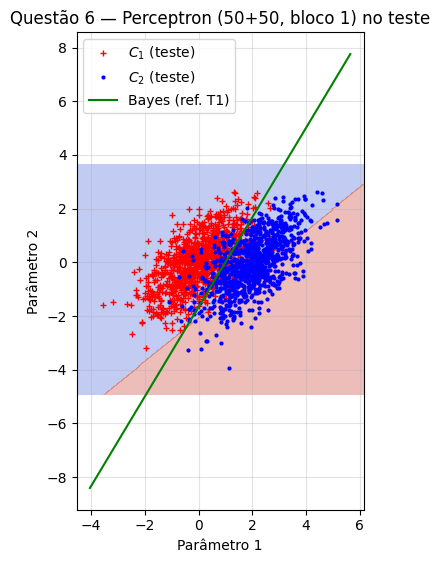

Figura: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho2\figures\questao6_perceptron_50_teste.png


In [4]:
# Questão 6 — 50+50 amostras (primeiro bloco, disjunto do da Q7)
rng_sub = np.random.default_rng(3030)
perm1 = rng_sub.permutation(n)
perm2 = rng_sub.permutation(n)
idx1_q6 = perm1[:50]
idx2_q6 = perm2[:50]

X1_q6 = X1[idx1_q6]
X2_q6 = X2[idx2_q6]
X_train_q6 = np.vstack([X1_q6, X2_q6])
y_train_q6 = np.concatenate([np.zeros(50, dtype=int), np.ones(50, dtype=int)])

clf_q6 = Perceptron(
    penalty=None,
    alpha=0.0,
    max_iter=5000,
    tol=1e-4,
    shuffle=True,
    eta0=0.1,
    random_state=0,
    early_stopping=False,
)
clf_q6.fit(X_train_q6, y_train_q6)
pred_q6 = clf_q6.predict(X_test)
err_q6 = 1.0 - accuracy_score(y_test, pred_q6)

print("Questão 6 — Perceptron (50+50, primeiro bloco)")
print(f"  Índices C1 (amostra): ... {idx1_q6[:5]} ... (total 50)")
print(f"  Índices C2 (amostra): ... {idx2_q6[:5]} ... (total 50)")
print(f"  n_iter_ = {clf_q6.n_iter_}")
print(f"  Erro estimado no teste: {err_q6:.4f}")

fig, ax = plt.subplots(figsize=(7.0, 6.2))
DecisionBoundaryDisplay.from_estimator(
    clf_q6,
    X_test,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.35,
    ax=ax,
    grid_resolution=250,
)
ax.plot(X1_test[:, 0], X1_test[:, 1], "r+", markersize=4, label="$C_1$ (teste)")
ax.plot(X2_test[:, 0], X2_test[:, 1], "b.", markersize=4, label="$C_2$ (teste)")
x1b = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 300)
x2b = -(w[0] * x1b + b) / w[1]
ax.plot(x1b, x2b, "g-", linewidth=1.5, label="Bayes (ref. T1)")
ax.set_xlabel("Parâmetro 1")
ax.set_ylabel("Parâmetro 2")
ax.set_title("Questão 6 — Perceptron (50+50, bloco 1) no teste")
ax.grid(True, alpha=0.35)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")
out6 = FIG_DIR / "questao6_perceptron_50_teste.png"
plt.savefig(out6, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura: {out6.resolve()}")

### Comentário (Questão 6)

Com apenas **50** exemplos por classe, a estimação da fronteira fica **mais ruidosa** do que com os $1000$ exemplos da Questão 5: o hiperplano ajusta-se a um subconjunto pequeno da nuvem Gaussiana, o que pode **melhorar ou piorar** o erro no teste dependendo de quão “sorteada” foi a amostra em relação à reta de Bayes. Compare o valor de $\hat{P}_e$ com o da Questão 5 e com o Bayes teórico (~$0{,}1056$).

## Questão 7 — Perceptron com **outros** 50 eventos por classe

Repetimos o procedimento da Questão 6, mas usando **outros** 50 pontos de cada classe: os índices `perm1[50:100]` e `perm2[50:100]`, **disjuntos** dos usados na Questão 6. Mesmos hiperparâmetros e mesmo conjunto de teste.

Questão 7 — Perceptron (50+50, segundo bloco)
  n_iter_ = 13
  Erro estimado no teste: 0.1080


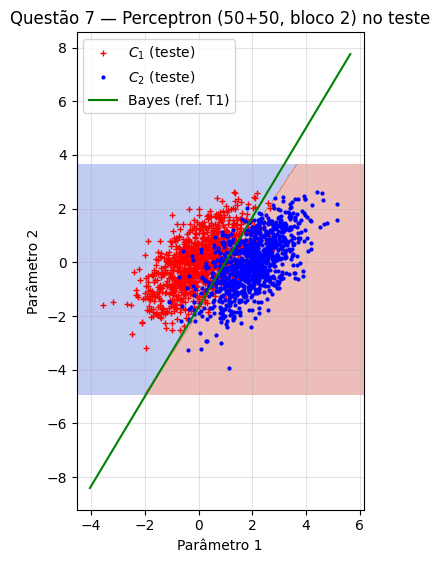

Figura: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho2\figures\questao7_perceptron_50_teste.png


In [5]:
# Questão 7 — outro bloco 50+50 (disjunto da Q6)
idx1_q7 = perm1[50:100]
idx2_q7 = perm2[50:100]

X1_q7 = X1[idx1_q7]
X2_q7 = X2[idx2_q7]
X_train_q7 = np.vstack([X1_q7, X2_q7])
y_train_q7 = np.concatenate([np.zeros(50, dtype=int), np.ones(50, dtype=int)])

clf_q7 = Perceptron(
    penalty=None,
    alpha=0.0,
    max_iter=5000,
    tol=1e-4,
    shuffle=True,
    eta0=0.1,
    random_state=0,
    early_stopping=False,
)
clf_q7.fit(X_train_q7, y_train_q7)
pred_q7 = clf_q7.predict(X_test)
err_q7 = 1.0 - accuracy_score(y_test, pred_q7)

print("Questão 7 — Perceptron (50+50, segundo bloco)")
print(f"  n_iter_ = {clf_q7.n_iter_}")
print(f"  Erro estimado no teste: {err_q7:.4f}")

fig, ax = plt.subplots(figsize=(7.0, 6.2))
DecisionBoundaryDisplay.from_estimator(
    clf_q7,
    X_test,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.35,
    ax=ax,
    grid_resolution=250,
)
ax.plot(X1_test[:, 0], X1_test[:, 1], "r+", markersize=4, label="$C_1$ (teste)")
ax.plot(X2_test[:, 0], X2_test[:, 1], "b.", markersize=4, label="$C_2$ (teste)")
x1b = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 300)
x2b = -(w[0] * x1b + b) / w[1]
ax.plot(x1b, x2b, "g-", linewidth=1.5, label="Bayes (ref. T1)")
ax.set_xlabel("Parâmetro 1")
ax.set_ylabel("Parâmetro 2")
ax.set_title("Questão 7 — Perceptron (50+50, bloco 2) no teste")
ax.grid(True, alpha=0.35)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")
out7 = FIG_DIR / "questao7_perceptron_50_teste.png"
plt.savefig(out7, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura: {out7.resolve()}")

### Comentário (Questão 7)

O segundo bloco de 50+50 é **estatisticamente independente** do primeiro (amostras diferentes), mas continua pequeno: a variância do perceptron entre Q6 e Q7 é esperada. Se um bloco caiu mais “próximo” da fronteira de Bayes ou numa região mais separável, o erro no teste pode **cair**; se caiu numa região mais confusa, **sobe**. A comparação **Q5 vs Q6 vs Q7** ilustra o compromisso **dados de treino vs. variância** para um classificador linear em dados **não separáveis**.

## Questão 8 — Classificador dos mínimos quadrados (pseudoinversa), treino completo

Projeta o hiperplano que minimiza $\sum_i \bigl(\underline{\theta}^\top \tilde{\underline{x}}_i - y_i\bigr)^2$ com **alvos** $y_i \in \{-1,+1\}$ ($C_1 \to -1$, $C_2 \to +1$), matriz aumentada $\tilde{X} = [\mathbf{1}\mid X]$ e solução fechada $\underline{\hat{\theta}} = \tilde{X}^{\#}\,\underline{y}$ (Moore–Penrose: `numpy.linalg.pinv`). A decisão é $\hat{y} = 1$ se $\tilde{x}^\top \underline{\hat{\theta}} \ge 0$, caso contrário $0$.

Sobre o **conjunto de teste** da Questão 4: plotar a reta $w_1 x_1 + w_2 x_2 + b = 0$ com $(b,w_1,w_2)=\underline{\hat{\theta}}$, estimar $\hat{P}_e$ e comentar.

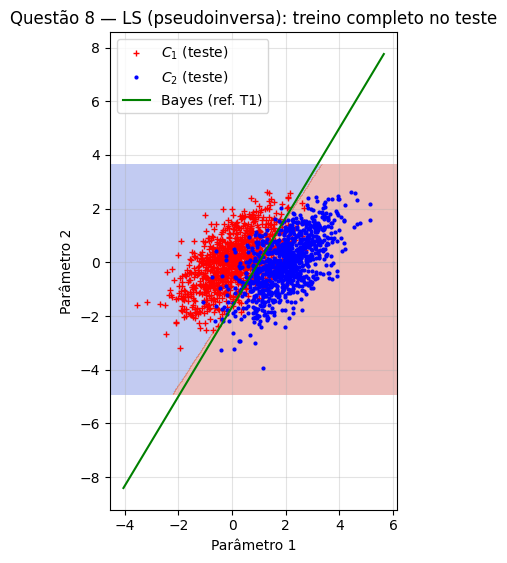

Figura: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho2\figures\questao8_ls_pinv_treino_completo_teste.png


In [6]:
# Questão 8 — mínimos quadrados (pseudoinversa), treino completo (mesmos X_train, y_train)
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score


def fit_ls_pinv(X, y01):
    """Retorna theta = [b, w1, w2] com alvos +1 / -1 (C2=1, C1=0 no y01)."""
    y_pm = 2.0 * y01.astype(float) - 1.0
    X_aug = np.hstack([np.ones((X.shape[0], 1)), X])
    theta = np.linalg.pinv(X_aug) @ y_pm
    return theta


def predict_ls(theta, X):
    X_aug = np.hstack([np.ones((X.shape[0], 1)), X])
    g = X_aug @ theta
    return (g >= 0.0).astype(int)


class LSBinaryClassifier(BaseEstimator, ClassifierMixin):
    """Classificador linear MQ (pseudoinversa em alvos ±1); rótulos 0/1."""

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.theta_ = np.asarray(fit_ls_pinv(X, y), dtype=float).ravel()
        self.coef_ = self.theta_[1:].reshape(1, -1)
        self.intercept_ = np.array([self.theta_[0]], dtype=float)
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        return predict_ls(self.theta_, np.asarray(X, dtype=float))


clf_ls8 = LSBinaryClassifier().fit(X_train, y_train)
theta_q8 = clf_ls8.theta_
pred_q8 = clf_ls8.predict(X_test)
err_q8 = 1.0 - accuracy_score(y_test, pred_q8)
print("Questão 8 — mínimos quadrados (pseudoinversa), treino completo")
print(f"  theta = [b, w1, w2] = {theta_q8}")
print(f"  Erro estimado no teste: {err_q8:.4f}")
fig, ax = plt.subplots(figsize=(7.0, 6.2))
DecisionBoundaryDisplay.from_estimator(
    clf_ls8,
    X_test,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.35,
    ax=ax,
    grid_resolution=250,
)
ax.plot(X1_test[:, 0], X1_test[:, 1], "r+", markersize=4, label="$C_1$ (teste)")
ax.plot(X2_test[:, 0], X2_test[:, 1], "b.", markersize=4, label="$C_2$ (teste)")
x1b = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 300)
x2b = -(w[0] * x1b + b) / w[1]
ax.plot(x1b, x2b, "g-", linewidth=1.5, label="Bayes (ref. T1)")
ax.set_xlabel("Parâmetro 1")
ax.set_ylabel("Parâmetro 2")
ax.set_title("Questão 8 — LS (pseudoinversa): treino completo no teste")
ax.grid(True, alpha=0.35)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")
out8 = FIG_DIR / "questao8_ls_pinv_treino_completo_teste.png"
plt.savefig(out8, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura: {out8.resolve()}")

### Comentário (Questão 8)

Com **$N=2000$** amostras e apenas **$l=2$** features (mais bias), tem-se $N \gg l$: o sistema está bem **sobredeterminado** e a pseudoinversa fornece o **mínimo da soma dos quadrados** dos resíduos nos alvos $\pm 1$. A fronteira é **linear**; para duas Gaussianas com a mesma covariância e priors iguais, a regra de **Bayes** também é linear — o LS costuma aproximar-se razoavelmente da reta ótima, com $\hat{P}_e$ comparável (em geral próximo) ao do perceptron treinado em todo o conjunto (Q5), sem iterações.

## Questão 9 — LS (pseudoinversa) com 50 eventos por classe (primeiro bloco)

Reutiliza o **mesmo** subconjunto **50+50** da Questão 6 (`X_train_q6`, `y_train_q6`). Exige ter executado a célula da Questão 6 antes.

Questão 9 — mínimos quadrados (50+50, bloco 1)
  theta = [-0.58627725  0.69507842 -0.41476462]
  Erro estimado no teste: 0.1110


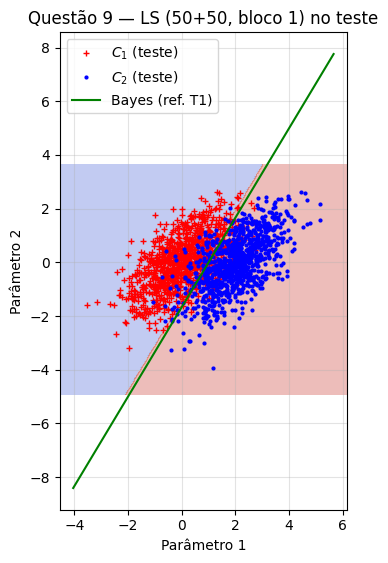

Figura: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho2\figures\questao9_ls_pinv_50_teste.png


In [7]:
# Questão 9 — LS com 50+50 (bloco 1 = Questão 6)
clf_ls9 = LSBinaryClassifier().fit(X_train_q6, y_train_q6)
theta_q9 = clf_ls9.theta_
pred_q9 = clf_ls9.predict(X_test)
err_q9 = 1.0 - accuracy_score(y_test, pred_q9)

print("Questão 9 — mínimos quadrados (50+50, bloco 1)")
print(f"  theta = {theta_q9}")
print(f"  Erro estimado no teste: {err_q9:.4f}")
fig, ax = plt.subplots(figsize=(7.0, 6.2))
DecisionBoundaryDisplay.from_estimator(
    clf_ls9,
    X_test,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.35,
    ax=ax,
    grid_resolution=250,
)
ax.plot(X1_test[:, 0], X1_test[:, 1], "r+", markersize=4, label="$C_1$ (teste)")
ax.plot(X2_test[:, 0], X2_test[:, 1], "b.", markersize=4, label="$C_2$ (teste)")
x1b = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 300)
x2b = -(w[0] * x1b + b) / w[1]
ax.plot(x1b, x2b, "g-", linewidth=1.5, label="Bayes (ref. T1)")
ax.set_xlabel("Parâmetro 1")
ax.set_ylabel("Parâmetro 2")
ax.set_title("Questão 9 — LS (50+50, bloco 1) no teste")
ax.grid(True, alpha=0.35)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")
out9 = FIG_DIR / "questao9_ls_pinv_50_teste.png"
plt.savefig(out9, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura: {out9.resolve()}")

### Comentário (Questão 9)

Com apenas **100** equações e **3** incógnitas, a solução LS ainda existe no sentido **MQ** (pseudoinversa), mas a estimativa de $\underline{\theta}$ fica **muito mais ruidosa** que com o treino completo: a reta pode afastar-se da de Bayes e o erro no teste pode **subir ou descer** em relação à Q8, conforme o sorteio dos 50 pontos (compare com a Questão 6 no perceptron).

## Questão 10 — LS (pseudoinversa) com **outros** 50+50 (segundo bloco)

Reutiliza o subconjunto da Questão 7 (`X_train_q7`, `y_train_q7`), **disjunto** do da Questão 9.

Questão 10 — mínimos quadrados (50+50, bloco 2)
  theta = [-0.58336234  0.60288672 -0.36630342]
  Erro estimado no teste: 0.1030


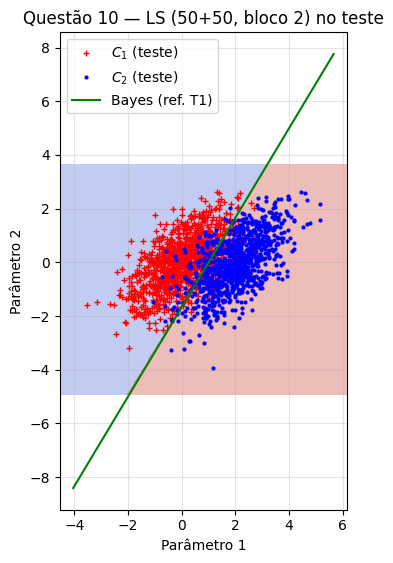

Figura: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho2\figures\questao10_ls_pinv_50_teste.png


In [8]:
# Questão 10 — LS com 50+50 (bloco 2 = Questão 7)
clf_ls10 = LSBinaryClassifier().fit(X_train_q7, y_train_q7)
theta_q10 = clf_ls10.theta_
pred_q10 = clf_ls10.predict(X_test)
err_q10 = 1.0 - accuracy_score(y_test, pred_q10)

print("Questão 10 — mínimos quadrados (50+50, bloco 2)")
print(f"  theta = {theta_q10}")
print(f"  Erro estimado no teste: {err_q10:.4f}")
fig, ax = plt.subplots(figsize=(7.0, 6.2))
DecisionBoundaryDisplay.from_estimator(
    clf_ls10,
    X_test,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.35,
    ax=ax,
    grid_resolution=250,
)
ax.plot(X1_test[:, 0], X1_test[:, 1], "r+", markersize=4, label="$C_1$ (teste)")
ax.plot(X2_test[:, 0], X2_test[:, 1], "b.", markersize=4, label="$C_2$ (teste)")
x1b = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 300)
x2b = -(w[0] * x1b + b) / w[1]
ax.plot(x1b, x2b, "g-", linewidth=1.5, label="Bayes (ref. T1)")
ax.set_xlabel("Parâmetro 1")
ax.set_ylabel("Parâmetro 2")
ax.set_title("Questão 10 — LS (50+50, bloco 2) no teste")
ax.grid(True, alpha=0.35)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")
out10 = FIG_DIR / "questao10_ls_pinv_50_teste.png"
plt.savefig(out10, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura: {out10.resolve()}")

### Comentário (Questão 10)

Tal como na Questão 7, **outro** bloco 50+50 altera a matriz $\tilde{X}$ e o vetor $\underline{y}$ na pseudoinversa, gerando outra reta MQ. Espera-se **variância** entre Q9 e Q10; a comparação com a **Q8** (treino completo) mostra o efeito de **tamanho amostral** na estabilidade da fronteira linear.

## Questão 11 — SVM linear com margem suave (treino completo)

Implementamos o classificador **SVM linear com margem suave** (`sklearn.svm.SVC` com `kernel="linear"`). O parâmetro **$C>0$** controla o compromisso entre **margem larga** e **penalização de violações** de $d_i(\mathbf{w}^\top\mathbf{x}_i+b)\ge 1$ (formação dual com caixa $0\le \alpha_i \le C$ nos slides / notas de aula; ver também `ClassLinear.pdf`).

Fixamos **`C = 1.0`** para todas as questões 11–13 (reprodutível e comparável). Sobre o **conjunto de teste** da Questão 4: fronteira, $\hat{P}_e$ e comentário.

Questão 11 — SVM linear (margem suave), treino completo
  C = 1.0
  n_support_ (total) = 525
  Erro estimado no teste: 0.1005


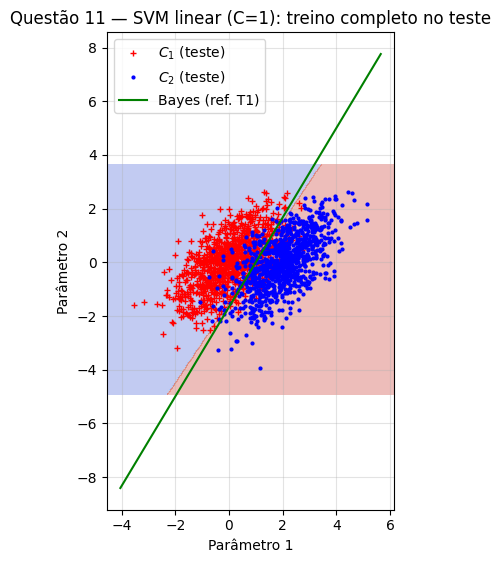

Figura: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho2\figures\questao11_svm_linear_teste.png


In [9]:
# Questão 11 — SVM linear margem suave, treino completo
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score

SVM_C = 1.0  # parâmetro de margem suave (mesmo nas Q12 e Q13)

svm_q11 = SVC(kernel="linear", C=SVM_C)
svm_q11.fit(X_train, y_train)
pred_q11 = svm_q11.predict(X_test)
err_q11 = 1.0 - accuracy_score(y_test, pred_q11)

print("Questão 11 — SVM linear (margem suave), treino completo")
print(f"  C = {SVM_C}")
print(f"  n_support_ (total) = {svm_q11.n_support_.sum()}")
print(f"  Erro estimado no teste: {err_q11:.4f}")

fig, ax = plt.subplots(figsize=(7.0, 6.2))
DecisionBoundaryDisplay.from_estimator(
    svm_q11,
    X_test,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.35,
    ax=ax,
    grid_resolution=250,
)
ax.plot(X1_test[:, 0], X1_test[:, 1], "r+", markersize=4, label="$C_1$ (teste)")
ax.plot(X2_test[:, 0], X2_test[:, 1], "b.", markersize=4, label="$C_2$ (teste)")
x1b = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 300)
x2b = -(w[0] * x1b + b) / w[1]
ax.plot(x1b, x2b, "g-", linewidth=1.5, label="Bayes (ref. T1)")
ax.set_xlabel("Parâmetro 1")
ax.set_ylabel("Parâmetro 2")
ax.set_title("Questão 11 — SVM linear (C=1): treino completo no teste")
ax.grid(True, alpha=0.35)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")
out11 = FIG_DIR / "questao11_svm_linear_teste.png"
plt.savefig(out11, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura: {out11.resolve()}")

### Comentário (Questão 11)

Com dados **não linearmente separáveis**, a margem suave permite **vetores de suporte** com $\alpha_i$ nos limites da caixa e amostras com margem violada — o hiperplano maximiza a margem **suavizada** pelo termo em $C$. Para duas Gaussianas com mesma $\Sigma$ e priors iguais, a fronteira de Bayes é **linear**; o SVM linear costuma aproximar-se bem, com erro de teste **comparável** ao MQ (Q8) e frequentemente **melhor** que o perceptron (Q5), dependendo de $C$ e do ruído.

## Questão 12 — SVM linear margem suave com 50 eventos por classe (bloco 1)

Mesmo **`C = 1.0`** e o subconjunto **50+50** da Questão 6 (`X_train_q6`, `y_train_q6`).

Questão 12 — SVM linear (50+50, bloco 1)
  n_support_ = 32
  Erro estimado no teste: 0.1140


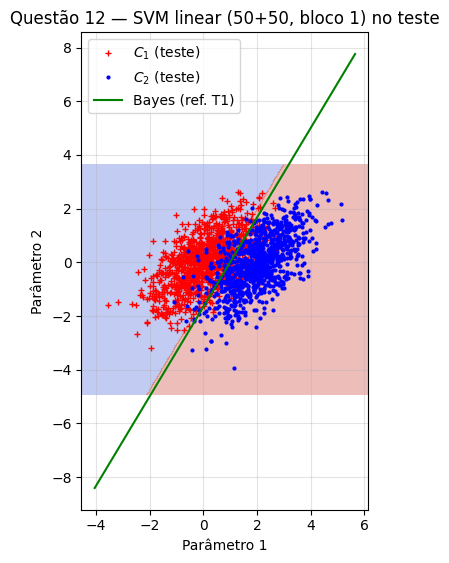

Figura: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho2\figures\questao12_svm_linear_50_teste.png


In [10]:
# Questão 12 — SVM linear, 50+50 bloco 1 (Questão 6)
svm_q12 = SVC(kernel="linear", C=SVM_C)
svm_q12.fit(X_train_q6, y_train_q6)
pred_q12 = svm_q12.predict(X_test)
err_q12 = 1.0 - accuracy_score(y_test, pred_q12)

print("Questão 12 — SVM linear (50+50, bloco 1)")
print(f"  n_support_ = {svm_q12.n_support_.sum()}")
print(f"  Erro estimado no teste: {err_q12:.4f}")

fig, ax = plt.subplots(figsize=(7.0, 6.2))
DecisionBoundaryDisplay.from_estimator(
    svm_q12,
    X_test,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.35,
    ax=ax,
    grid_resolution=250,
)
ax.plot(X1_test[:, 0], X1_test[:, 1], "r+", markersize=4, label="$C_1$ (teste)")
ax.plot(X2_test[:, 0], X2_test[:, 1], "b.", markersize=4, label="$C_2$ (teste)")
x1b = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 300)
x2b = -(w[0] * x1b + b) / w[1]
ax.plot(x1b, x2b, "g-", linewidth=1.5, label="Bayes (ref. T1)")
ax.set_xlabel("Parâmetro 1")
ax.set_ylabel("Parâmetro 2")
ax.set_title("Questão 12 — SVM linear (50+50, bloco 1) no teste")
ax.grid(True, alpha=0.35)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")
out12 = FIG_DIR / "questao12_svm_linear_50_teste.png"
plt.savefig(out12, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura: {out12.resolve()}")

### Comentário (Questão 12)

Com **poucos** pontos, o número e a posição dos **vetores de suporte** mudam bastante; a reta pode afastar-se da de Bayes. Compare com a **Q11** (treino completo) e com o perceptron na **Q6** (mesmo subconjunto, critério diferente).

## Questão 13 — SVM linear margem suave com **outros** 50+50 (bloco 2)

Mesmo **`C = 1.0`** e o subconjunto da Questão 7 (`X_train_q7`, `y_train_q7`), disjunto do da Q12.

Questão 13 — SVM linear (50+50, bloco 2)
  n_support_ = 33
  Erro estimado no teste: 0.1050


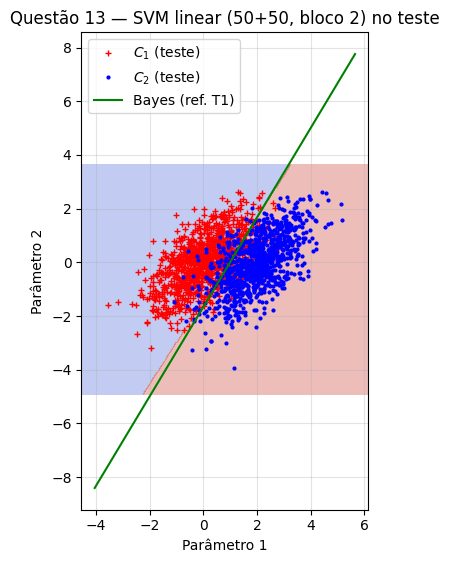

Figura: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\trabalho2\figures\questao13_svm_linear_50_teste.png


In [11]:
# Questão 13 — SVM linear, 50+50 bloco 2 (Questão 7)
svm_q13 = SVC(kernel="linear", C=SVM_C)
svm_q13.fit(X_train_q7, y_train_q7)
pred_q13 = svm_q13.predict(X_test)
err_q13 = 1.0 - accuracy_score(y_test, pred_q13)

print("Questão 13 — SVM linear (50+50, bloco 2)")
print(f"  n_support_ = {svm_q13.n_support_.sum()}")
print(f"  Erro estimado no teste: {err_q13:.4f}")

fig, ax = plt.subplots(figsize=(7.0, 6.2))
DecisionBoundaryDisplay.from_estimator(
    svm_q13,
    X_test,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.35,
    ax=ax,
    grid_resolution=250,
)
ax.plot(X1_test[:, 0], X1_test[:, 1], "r+", markersize=4, label="$C_1$ (teste)")
ax.plot(X2_test[:, 0], X2_test[:, 1], "b.", markersize=4, label="$C_2$ (teste)")
x1b = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 300)
x2b = -(w[0] * x1b + b) / w[1]
ax.plot(x1b, x2b, "g-", linewidth=1.5, label="Bayes (ref. T1)")
ax.set_xlabel("Parâmetro 1")
ax.set_ylabel("Parâmetro 2")
ax.set_title("Questão 13 — SVM linear (50+50, bloco 2) no teste")
ax.grid(True, alpha=0.35)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")
out13 = FIG_DIR / "questao13_svm_linear_50_teste.png"
plt.savefig(out13, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura: {out13.resolve()}")

### Comentário (Questão 13)

O segundo bloco 50+50 altera quais pontos entram na **margem** e quais viram suportes; espera-se **variância** entre Q12 e Q13 em relação ao erro no teste, como nas Q7 vs Q6 no perceptron.